In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

In [3]:
model = joblib.load("artifacts/xgb_model.pkl")
preprocessor = joblib.load("artifacts/preprocessor.pkl")
feature_names = joblib.load("artifacts/feature_names.pkl")

In [4]:
print(type(model))
print(type(preprocessor))
print(len(feature_names))

<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
45


In [5]:
df = pd.read_csv("data/processed/cleaned_data.csv")

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
X_test_processed = preprocessor.transform(X_test)

In [8]:
print(X_test_processed.shape)

(1402, 45)


In [9]:
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [11]:
X_test_processed_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
743,-0.440402,-1.123280,-0.705606,-0.924550,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
668,-0.440402,1.540485,-0.246715,0.768509,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
5741,2.270655,1.007732,0.953076,1.468408,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
5449,-0.440402,0.024188,0.460812,0.123213,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2020,-0.440402,-1.246223,-0.141587,-0.954355,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [12]:
explainer = shap.TreeExplainer(model)

In [13]:
shap_values = explainer.shap_values(X_test_processed_df)

In [14]:
print(shap_values.shape)

(1402, 45)


## Global Feature Importance

>What features help to derive churn

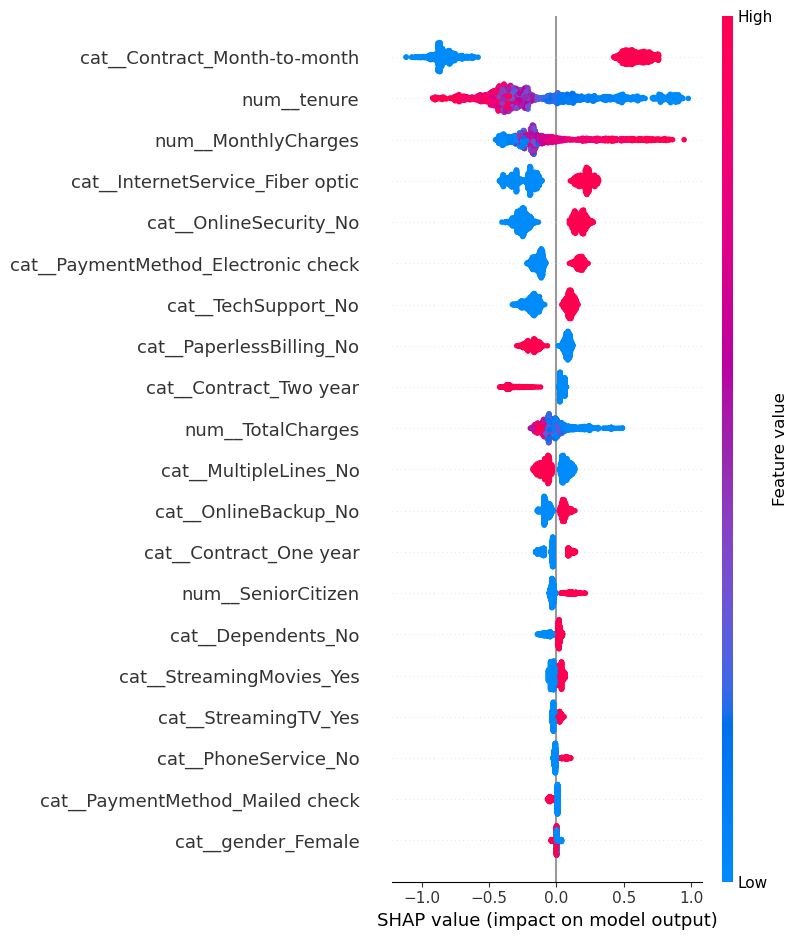

In [15]:
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    show=True
)

>shap help to know which features have the greatest influence on the XGBoost churn predictions. The summary plot shows both feature importance and the direction of each feature's contribution.
>
>contract type, tenure, monthly charges, internet service, online security, payment method, and technical support were among the most influenced features.

## Local Feature Importance

> Why did this particular customer get a high/low churn prediction?

In [19]:
y_test_pred_proba = model.predict_proba(X_test_processed)[:, 1]

y_test_pred = (y_test_pred_proba >= 0.35).astype(int)

pd.DataFrame({
    "actual": y_test,
    "probability": y_test_pred_proba,
    "prediction": y_test_pred
}).head(10)

,actual,probability,prediction
743,No,0.376967,1
668,No,0.036367,0
5741,No,0.081103,0
5449,No,0.313994,0
2020,No,0.254129,0
3067,Yes,0.371358,1
5178,No,0.075331,0
2035,No,0.124302,0
4281,No,0.183142,0
3001,No,0.125628,0


high-risk customer from the test set

In [20]:
results = pd.DataFrame({
    "actual": y_test,
    "probability": y_test_pred_proba,
    "prediction": y_test_pred
}, index=y_test.index)

results.sort_values("probability", ascending=False).head(10)

,actual,probability,prediction
2198,Yes,0.911425,1
2734,Yes,0.875520,1
979,Yes,0.868771,1
6719,Yes,0.863246,1
2454,Yes,0.861197,1
3806,Yes,0.852922,1
6977,Yes,0.852922,1
3735,Yes,0.850356,1
641,Yes,0.849445,1
5121,No,0.849445,1


In [21]:
# Find position of customer 2198 in X_test_processed
customer_pos = X_test.index.get_loc(2198)


customer_shap = explainer.shap_values(
    X_test_processed[customer_pos:customer_pos+1]
)

customer_shap

array([[ 8.8299409e-02,  8.2798505e-01,  4.0788078e-01,  2.5726101e-01,
        -4.2200200e-03,  0.0000000e+00,  5.3500303e-04,  0.0000000e+00,
         2.3903800e-02,  0.0000000e+00, -6.9151795e-03,  0.0000000e+00,
         1.0552159e-01,  0.0000000e+00, -4.4373428e-03,  2.4888404e-03,
         2.2180782e-01,  0.0000000e+00,  1.8672656e-01,  0.0000000e+00,
        -2.5253702e-04,  8.4050655e-02,  0.0000000e+00,  3.3810016e-04,
         1.1836105e-02,  0.0000000e+00,  3.2893274e-02,  1.3276300e-01,
         0.0000000e+00,  2.7064132e-03,  0.0000000e+00,  0.0000000e+00,
         1.5379265e-02,  1.0831695e-02,  0.0000000e+00,  1.1233425e-02,
         6.9242620e-01, -3.2397404e-02,  3.3076487e-02,  8.5946195e-02,
         0.0000000e+00, -7.4121496e-04,  3.9891452e-03,  1.6080239e-01,
         3.6059264e-03]], dtype=float32)

In [25]:

feature_names = preprocessor.get_feature_names_out()

# Create a dataframe for customer 2198
local_shap = pd.DataFrame({
    "feature": feature_names,
    "shap_value": customer_shap[0]
})

# Sort by absolute SHAP value
local_shap["abs_shap"] = local_shap["shap_value"].abs()

local_shap = local_shap.sort_values(
    "abs_shap",
    ascending=False
)

local_shap.head(10)

,feature,shap_value,abs_shap
1,num__tenure,0.827985,0.827985
36,cat__Contract_Month-to-month,0.692426,0.692426
2,num__MonthlyCharges,0.407881,0.407881
3,num__TotalCharges,0.257261,0.257261
16,cat__InternetService_Fiber optic,0.221808,0.221808
18,cat__OnlineSecurity_No,0.186727,0.186727
43,cat__PaymentMethod_Electronic check,0.160802,0.160802
27,cat__TechSupport_No,0.132763,0.132763
12,cat__MultipleLines_No,0.105522,0.105522
0,num__SeniorCitizen,0.088299,0.088299


In [24]:
X_test.loc[2198]

gender                        Female
SeniorCitizen                      1
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                 Yes
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 100.8
TotalCharges                   100.8
Name: 2198, dtype: object

## top 10 high-risk customers with Local SHAP to use that analysis to identify the patterns

In [26]:
top_10 = results.sort_values(
    "probability",
    ascending=False
).head(10)

top_10

,actual,probability,prediction
2198,Yes,0.911425,1
2734,Yes,0.875520,1
979,Yes,0.868771,1
6719,Yes,0.863246,1
2454,Yes,0.861197,1
3806,Yes,0.852922,1
6977,Yes,0.852922,1
3735,Yes,0.850356,1
641,Yes,0.849445,1
5121,No,0.849445,1


In [27]:
top_10_shap = []

for customer_id in top_10.index:
    
    customer_pos = X_test.index.get_loc(customer_id)
    
    shap_value = explainer.shap_values(
        X_test_processed[customer_pos:customer_pos + 1]
    )[0]
    
    top_10_shap.append(shap_value)

In [28]:
top_10_shap_df = pd.DataFrame(
    top_10_shap,
    index=top_10.index,
    columns=feature_names
)

top_10_shap_df

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
2198,0.088299,0.827985,0.407881,0.257261,-0.004220,0.0,0.000535,0.0,0.023904,0.0,...,0.011233,0.692426,-0.032397,0.033076,0.085946,0.0,-0.000741,0.003989,0.160802,0.003606
2734,0.097807,0.837947,0.053413,0.216999,0.002019,0.0,0.000403,0.0,0.023904,0.0,...,-0.008972,0.758577,-0.030360,0.031209,0.081209,0.0,-0.000741,0.003989,0.174556,0.003606
979,-0.025401,0.842883,0.060746,0.212777,0.002019,0.0,0.000541,0.0,0.023904,0.0,...,0.011233,0.754572,-0.031368,0.029183,0.096651,0.0,-0.000650,0.003989,0.179704,0.003918
6719,0.079426,0.894627,0.045235,0.247246,-0.001904,0.0,0.000541,0.0,0.020385,0.0,...,0.011233,0.754803,-0.031368,0.030176,0.072418,0.0,-0.000650,0.003989,0.156680,0.003606
2454,-0.025401,0.849835,-0.007266,0.230538,-0.001904,0.0,0.000849,0.0,0.023904,0.0,...,-0.008972,0.756971,-0.029900,0.027720,0.103038,0.0,-0.000650,0.004878,0.208641,0.003918
3806,0.108251,0.795905,-0.118109,0.226612,-0.001904,0.0,0.000849,0.0,0.018404,0.0,...,-0.008972,0.757890,-0.029900,0.029097,0.100821,0.0,-0.000650,0.004878,0.194375,0.003606
6977,0.108251,0.796368,-0.118109,0.226612,-0.001904,0.0,0.000403,0.0,0.018404,0.0,...,-0.008972,0.757890,-0.029900,0.030999,0.099178,0.0,-0.000741,0.004878,0.194375,0.003606
3735,0.087138,0.558963,0.258351,0.141703,0.003943,0.0,0.000541,0.0,0.023737,0.0,...,0.011860,0.697682,-0.031143,0.023333,0.089729,0.0,-0.000650,0.002440,0.165072,0.006963
641,-0.017902,0.877136,0.055893,0.229527,0.002019,0.0,0.000541,0.0,0.020385,0.0,...,0.011233,0.753918,-0.031828,0.029448,0.074286,0.0,-0.000650,0.003989,0.165642,0.003918
5121,-0.017902,0.878746,0.054492,0.229527,0.002019,0.0,0.000541,0.0,0.020385,0.0,...,0.011233,0.753918,-0.031828,0.029448,0.074286,0.0,-0.000650,0.003989,0.165642,0.003918


In [29]:
for customer_id in top_10_shap_df.index:
    
    print(f"\nCustomer: {customer_id}")
    print(f"Churn Probability: {top_10.loc[customer_id, 'probability']:.2%}")
    
    customer_features = top_10_shap_df.loc[customer_id]
    
    print(
        customer_features.abs()
        .sort_values(ascending=False)
        .head(5)
    )


Customer: 2198
Churn Probability: 91.14%
num__tenure                         0.827985
cat__Contract_Month-to-month        0.692426
num__MonthlyCharges                 0.407881
num__TotalCharges                   0.257261
cat__InternetService_Fiber optic    0.221808
Name: 2198, dtype: float32

Customer: 2734
Churn Probability: 87.55%
num__tenure                         0.837947
cat__Contract_Month-to-month        0.758577
num__TotalCharges                   0.216999
cat__InternetService_Fiber optic    0.216536
cat__OnlineSecurity_No              0.210442
Name: 2734, dtype: float32

Customer: 979
Churn Probability: 86.88%
num__tenure                         0.842883
cat__Contract_Month-to-month        0.754572
cat__OnlineSecurity_No              0.228693
cat__InternetService_Fiber optic    0.223508
num__TotalCharges                   0.212777
Name: 979, dtype: float32

Customer: 6719
Churn Probability: 86.32%
num__tenure                         0.894627
cat__Contract_Month-to-month     

In [30]:
top_10_customers = X_test.loc[top_10.index]

top_10_customers

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
2198,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.80,100.80
2734,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,86.05,86.05
979,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.60,86.60
6719,Female,1,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,85.00,85.00
2454,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,77.15,77.15
3806,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.20,74.20
6977,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,74.45
3735,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.85,196.75
641,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.55,89.55
5121,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.25,89.25


The top 10 customers with the highest predicted churn probability were analyzed using SHAP to identify the key features contributing to their predictions.

| Pattern                      |                          Top 10 |
| ---------------------------- | ------------------------------: |
| Fiber optic                  |                       **10/10** |
| Month-to-month contract      |                       **10/10** |
| Electronic check             |                       **10/10** |
| No Online Security           |                       **10/10** |
| No Online Backup             |                       **10/10** |
| No Device Protection         |                       **10/10** |
| No Dependents                |                       **10/10** |
| No Paperless Billing?        | **0/10** — actually Yes for all |
| Very low tenure (1–2 months) |                       **10/10** |
| No Tech Support              |                        **9/10** |
| Monthly charges ~₹74–₹101    |                       **10/10** |
